In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from attack import *

In [2]:
data = {}
p = 1
N = 10
epsilons = [10, 1, 0.1]

for attack in [lbfgs, projected_gradient_descent, frank_wolfe, fgsm, ifgsm, mifgsm]:
    rates = []
    for e in epsilons:
        if attack == fgsm:
            N_ = 1
        else:
            N_ = N
        df = pd.read_csv(f'results/l{p}/{attack.__name__}-e{e}-p{p}-N{N_}.csv')
        rates.append(len(df[df['success'] == True]) / len(df) * 100)
    data[attack.__name__] = rates

result_table = pd.DataFrame(data, index=[f'eps={e}' for e in epsilons])
print(result_table.to_string(float_format="%.5g"))

          lbfgs  projected_gradient_descent  frank_wolfe    fgsm   ifgsm  mifgsm
eps=10   89.746                      18.984       23.359  11.777  29.023  28.301
eps=1   0.11719                     0.83984       7.7734  5.4883  8.4375  7.8906
eps=0.1 0.27344                     0.91797      0.95703 0.70312 0.97656 0.95703


In [3]:
data = {}
p = 1
N = 10
epsilons = [10, 1, 0.1]

for attack in [lbfgs, projected_gradient_descent, frank_wolfe, fgsm, ifgsm, mifgsm]:
    rates = []
    for e in epsilons:
        if attack == fgsm:
            N_ = 1
        else:
            N_ = N
        df = pd.read_csv(f'results/l{p}/{attack.__name__}-e{e}-p{p}-N{N_}.csv')
        rates.append(df[df['success']]['l1'].mean())
    data[attack.__name__] = rates

result_table = pd.DataFrame(data, index=[f'eps={e}' for e in epsilons])
print(result_table.to_string(float_format="%.5g"))

             lbfgs  projected_gradient_descent  frank_wolfe  fgsm  ifgsm  mifgsm
eps=10  2.8206e+05                          10       9.9906    10 9.9233  9.9959
eps=1      0.81387                           1      0.99525     1 0.9963       1
eps=0.1    0.67936                         0.1          0.1   0.1    0.1     0.1


In [4]:
attack = ifgsm
p=1
N=10

for i, e in enumerate([10, 1, 0.1, 0.01]):
    df = pd.read_csv(f'results/l{p}/{attack.__name__}-e{e}-p{p}-N{N}.csv')
    current_success = set(df[df['success'] == True]["global_index"])
    if i == 0:
        indices = current_success
    else:
        indices.intersection_update(current_success)

In [5]:
df = pd.read_csv(f'results/l{p}/{attack.__name__}-e{0.01}-p{p}-N{N}.csv')
df_succ = df[df['success'] == True]
filtered_df = df_succ[df_succ['global_index'].isin(indices)]

df_succ["global_index"].iloc[filtered_df["prob_org"].argmax()]

# 4047 for horse example
# extreme 1 pixel case: 2941

np.int64(2941)

In [6]:
attack = fgsm
e=1
p=2
N=1

df = pd.read_csv(f'results/l{p}/{attack.__name__}-e{e}-p{p}-N{N}.csv')

df_succ = df[df['success'] == True]
df_fail = df[df['success'] == False]

<function matplotlib.pyplot.show(close=None, block=None)>

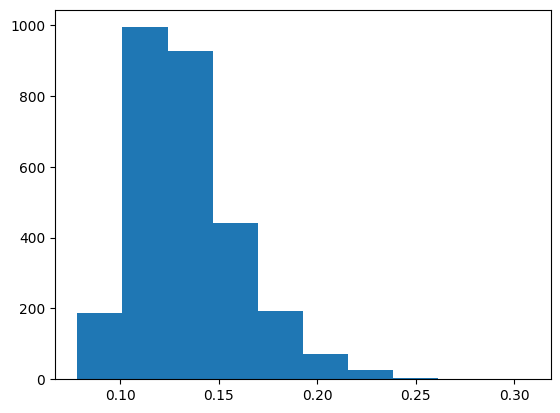

In [7]:
plt.hist(df_succ["linf"])
plt.show

In [8]:
print(f'Attack success rate: {len(df_succ) / len(df):.2%}')
print(f'Average time: {df['times'].mean():.5f} seconds')
print(f'Average Linf norm: {df["linf"].mean():.5f}')
print(f'Average L2 norm: {df["l2"].mean():.5f}')
print(f'Average L1 norm: {df["l1"].mean():.5f}')

Attack success rate: 55.51%
Average time: 0.00231 seconds
Average Linf norm: 0.13232
Average L2 norm: 1.00000
Average L1 norm: 36.42623


In [9]:
df_succ["global_index"].iloc[df_succ["prob_org"].argmax()]

np.int64(351)

In [10]:
from cifar10_resnet20 import *
from utils import *

from torch.utils.data import Subset, DataLoader

indices = get_correct_indices(model, testloader, 512)
subset = Subset(testset, indices)
loader = DataLoader(subset, batch_size=128, shuffle=False)

/Users/sanyangliu/Documents/code_projects/adversarial-attack-on-image-classifier/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


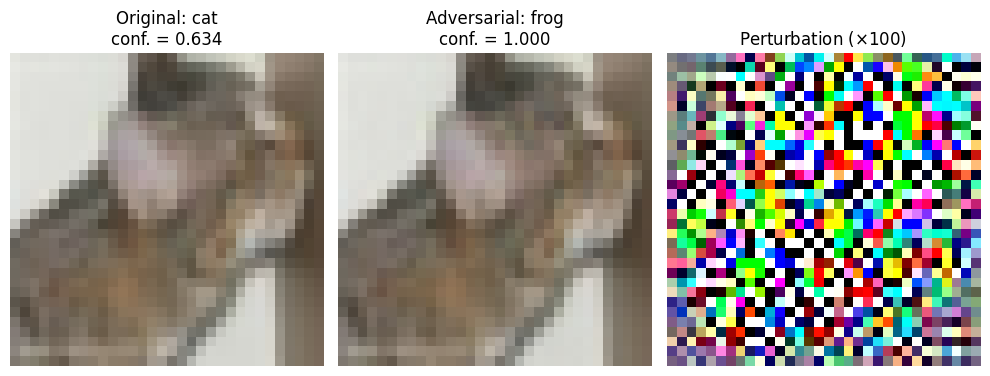

In [11]:
idx = 1634
x0, y = subset[idx]
d = attack(model, x0.unsqueeze(0), torch.tensor([y]), e=e, p=p, N=N)
show_adversarial_example(model, x0, y, d.squeeze(0))

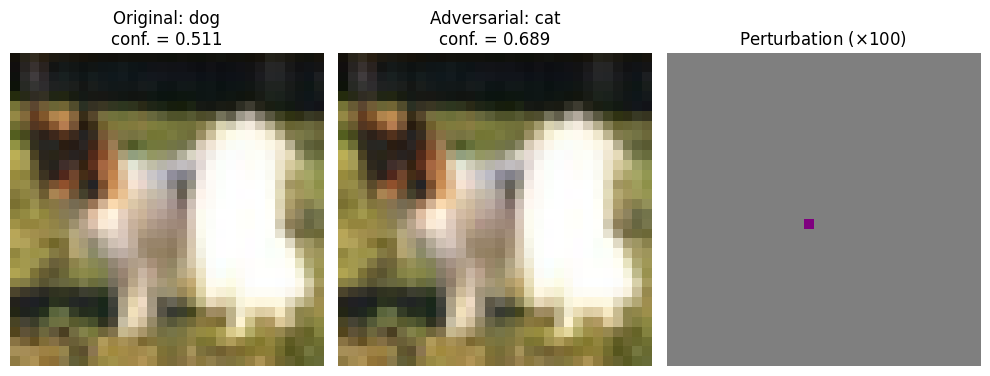

In [12]:
attack = ifgsm
p = 1
N = 10
e = 0.1
idx = 2941
x0, y = subset[idx]
d = attack(model, x0.unsqueeze(0), torch.tensor([y]), e=e, p=p, N=N)

show_adversarial_example(model, x0, y, d.squeeze(0))